In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
x            -1.000000
y_noise_1    11.624419
y_noise_2     8.296963
y_noise_3    12.201067
y_noise_4     7.811725
y_noise_5     3.155566
Name: 0, dtype: float64


/var/folders/cx/z2wpfgp17_gb11ky42gr1zkh0000gn/T/ipykernel_53460/1105645849.py:13: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-k*x)


Text(0.5, 1.0, 'Chi-squared: 77.49')

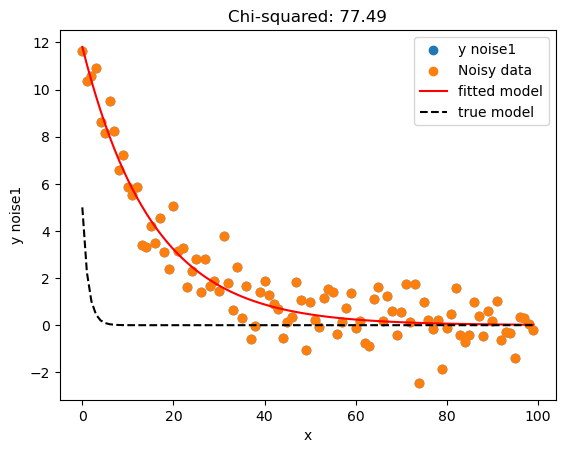

In [2]:
curvefit_data = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")
print(curvefit_data.shape) #100 rows 6 cols
print(curvefit_data.head(),curvefit_data.tail())
print(curvefit_data.loc[0])
x = np.linspace(0,len(curvefit_data)-1,len(curvefit_data))
y_noise_1 = curvefit_data["y_noise_1"]
plt.scatter(x,y_noise_1,label = "y noise1")
plt.title("x vs y noise1")
plt.xlabel("x")
plt.ylabel("y noise1")
plt.legend()
def model(x, A, k):
    return A*np.exp(-k*x)
p0 = [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

plt.scatter(x, y_noise_1, label='Noisy data')
plt.plot(x,model(x,A_fit,k_fit),label = "fitted model",color = "red")
plt.plot(x,model(x, 5, 0.8),label = "true model", linestyle="--", color = "black")
plt.legend()
plt.title(f"Chi-squared: {chi2:.2f}")

/var/folders/cx/z2wpfgp17_gb11ky42gr1zkh0000gn/T/ipykernel_53460/1105645849.py:13: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-k*x)


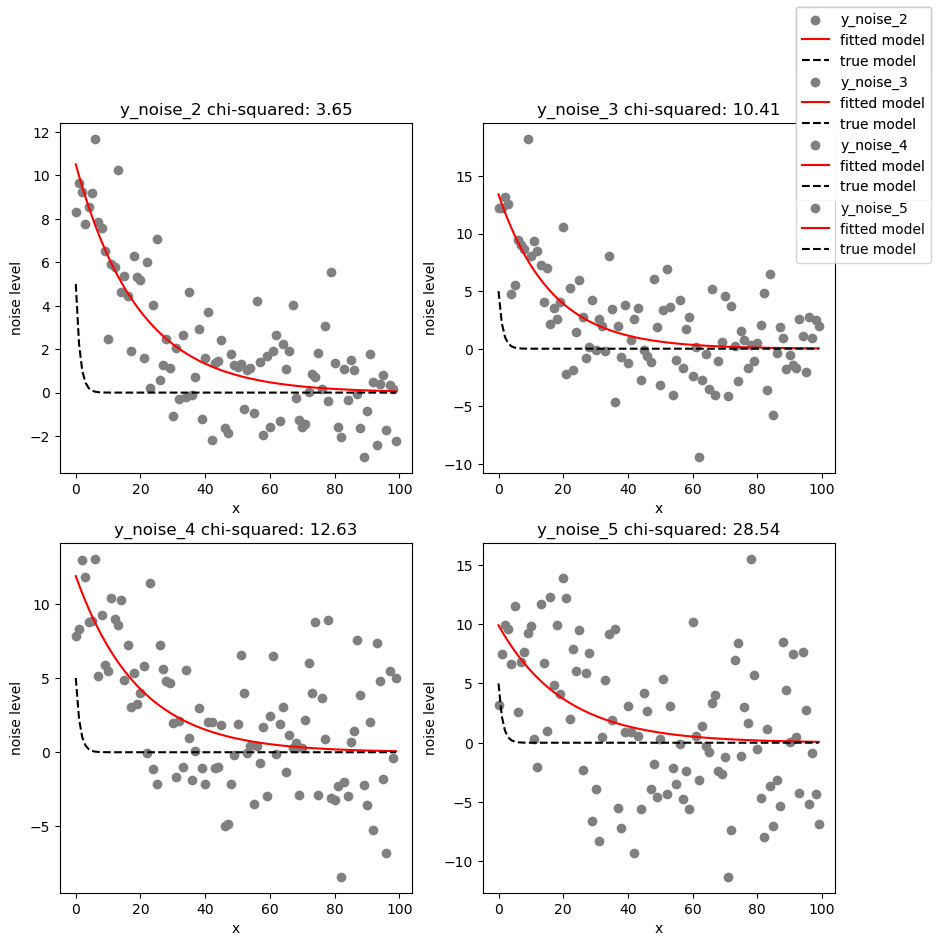

In [3]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced

fit_model(x,curvefit_data["y_noise_2"])[0]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plots = [(0,0),(0,1),(1,0),(1,1)]
y_noises = ["y_noise_2","y_noise_3","y_noise_4","y_noise_5"]

for plot,y_noise in zip(plots,y_noises):
    row, col = plot
    axes[row,col].scatter(x,curvefit_data[y_noise],color = "grey", label = y_noise)
    A_fit = fit_model(x,curvefit_data[y_noise])[0][0]
    k_fit = fit_model(x,curvefit_data[y_noise])[0][1]
    chi2 = f"{fit_model(x,curvefit_data[y_noise])[1]:.2f}"
    axes[row,col].plot(x,model(x,A_fit,k_fit), label = "fitted model", color = "red")
    axes[row,col].plot(x,model(x, 5, 0.8),label = "true model", linestyle="--", color = "black")
    axes[row,col].set_title(f"{y_noise} chi-squared: {chi2}")
    axes[row,col].set_xlabel("x")
    axes[row,col].set_ylabel("noise level")
    fig.legend()

#the red and dotted lines seem to get closer as you increase noise level?
#red chi2 also increases as you increase noise level

In [4]:
df = pd.DataFrame()
A_fits = []
k_fits = []
chi2s = []
noise_levels = ["y_noise_1","y_noise_2","y_noise_3","y_noise_4","y_noise_5"]
for noiselev in noise_levels:
    A_fit = fit_model(x,curvefit_data[noiselev])[0][0]
    k_fit = fit_model(x,curvefit_data[noiselev])[0][1]
    chi2 = fit_model(x,curvefit_data[noiselev])[1]
    A_fits.append(A_fit)
    k_fits.append(k_fit)
    chi2s.append(chi2)

df["Noise Level"] = noise_levels
df["A_fit"] = A_fits
df["k_fit"] = k_fits
df["Reduced chi-squared"] = chi2s
df.to_csv("noisy_parameters.csv", index=False)

/var/folders/cx/z2wpfgp17_gb11ky42gr1zkh0000gn/T/ipykernel_53460/1105645849.py:13: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-k*x)
